### reference
##### Tawara
https://www.kaggle.com/code/ttahara/birdclef-2026-hgnetv2-b0-baseline-inference
##### hengck23
https://www.kaggle.com/code/hengck23/pytorch-differentiable-perchv2

In [1]:
!pip install --no-index \
    -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt \
    --find-links=/kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels

Looking in links: /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/openvino-2026.0.0-20965-cp312-cp312-manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 1))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxscript-0.6.2-py3-none-any.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 2))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxsim-0.6.2-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 3))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxruntime-1.24.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2

In [2]:
import openvino as ov
print(f"Openvio version {ov.__version__}")

Openvio version 2026.0.0-20965-c6d6a13a886-releases/2026/0


In [3]:
import os
import gc
import sys
import math
import json
import joblib
import random
import numpy as np
import pandas as pd
import typing as tp
from time import time
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import ast
from pathlib import Path
from itertools import islice
from collections import Counter, defaultdict

import wave
import soundfile

import librosa
import soundfile as sf
from IPython.display import Audio, display

import torch
import torchaudio
from torchvision.transforms import v2 as tvt_v2

from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata
import scipy

from collections import Counter

# Timm
import timm
print(f"Timm Version {timm.__version__}")

import glob
import warnings
warnings.filterwarnings("ignore")

Timm Version 1.0.25


In [4]:
class CFG():
    SEED            = 1028
    N_FOLDS         = 5
    FOLDS_LIST      = [0, 2]
    base_dir        = "/kaggle/input/competitions/birdclef-2026"
    ss_dir          = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-ss-wav-data"
    label_dir       = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-5fold-df-and-ss/data"
    model_name_lse  = "efficientnet_b0"
    model_name_gemf = "tf_efficientnet_b0.ns_jft_in1k"
    model_lse_f1    = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-lsehead-b0-model"
    model_lse_f3    = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold3-lsehead-b0-model"
    model_gemf_f1   = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-gemf-b0-model"
    model_gemf_f3   = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold3-gemf-b0-model"
    
    # Librosa
    SAMPLING_RATE = 32_000
    N_FFT         = 2_048
    HOP_LEN       = 512
    N_MELS        = 128
    FMIN          = 20
    FMAX          = 16_000
    DURATION      = 5
    # Targets
    NUM_CLASS     = 234
    # segments & context
    SEGMENT_SEC   = 5
    CONTEXT_SEC   = 20
    # Mel
    TOP_DB_LSE    = 60
    TOP_DB_GeMF   = 80
    # TTA
    TTA_SHIFTS    = [-2, -1, 0, 1, 2]
    # GAUSSIAN
    USE_GAUSSIAN  = True

    # Debug
    debug         = False
    weight_search = False
        
cfg = CFG()
print(f"fram : {(cfg.SAMPLING_RATE*cfg.CONTEXT_SEC)/cfg.HOP_LEN}")

#128 周波数方向（mel bins）
#626 時間方向（time frames）

fram : 1250.0


### Make Directry

In [5]:
MODEL_DIR = "/kaggle/working/onnx"
os.makedirs(MODEL_DIR, exist_ok=True)

### SeedEverything

In [6]:
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    
seed_everything(cfg.SEED)

### DATA

In [7]:
def load_labels(path):
    with open(path, mode="r") as f:
        labels_dict = json.load(f)
    return {int(k):v for k, v in labels_dict.items()}

### Lavel

In [8]:
idx2label = load_labels(os.path.join(cfg.label_dir, "idx2label.json"))
label2idx = {v:k for k, v in idx2label.items()}

In [9]:
sample_submission = pd.read_csv(os.path.join(cfg.base_dir, "sample_submission.csv"))
sample_submission.head()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [10]:
sample_submission.columns[1:].tolist() == list(label2idx.keys())

True

In [11]:
species_list = list(label2idx.keys())

def build_5sec_labels(df, species_list, label2idx):
    num_classes = len(species_list)
    rows = []

    for _, row in df.iterrows():
        fname = row["filename"]
        labels = row["labels"]

        start = row["start"]
        end   = row["end"]

        # 5秒単位に展開
        for t in range(5, 61, 5):
            seg_start = t - 5
            seg_end   = t

            # overlap判定
            if not (end <= seg_start or start >= seg_end):
                row_id = f"{fname.replace('.ogg','')}_{t}"

                label_vec = np.zeros(num_classes, dtype=np.float32)

                for l in labels:
                    idx = label2idx.get(l, None)
                    if idx is not None:
                        label_vec[idx] = 1.0

                rows.append([row_id, label_vec])

    # DataFrame化
    out = {}
    for row_id, label_vec in rows:
        if row_id not in out:
            out[row_id] = label_vec
        else:
            out[row_id] = np.maximum(out[row_id], label_vec)

    row_ids = list(out.keys())
    labels  = np.stack(list(out.values()))

    label_df = pd.DataFrame(labels, columns=species_list)
    label_df.insert(0, "row_id", row_ids)

    return label_df

In [12]:
def get_dummy_df():

    train_ss_df = pd.read_csv(
        os.path.join(cfg.base_dir, "train_soundscapes_labels.csv")
    )
    train_ss_df = train_ss_df.drop_duplicates().reset_index(drop=True)

    train_ss_df["labels"] = train_ss_df["primary_label"].str.split(";")

    FORMAT = "%H:%M:%S"
    train_ss_df["start"] = pd.to_datetime(train_ss_df["start"], format=FORMAT, errors="coerce")
    train_ss_df["end"]   = pd.to_datetime(train_ss_df["end"],   format=FORMAT, errors="coerce")

    train_ss_df["start"] = train_ss_df["start"].dt.minute * 60 + train_ss_df["start"].dt.second
    train_ss_df["end"]   = train_ss_df["end"].dt.minute   * 60 + train_ss_df["end"].dt.second

    # =========================
    # select 12segmentation
    # =========================
    # counts      = train_ss_df.groupby("filename").size()
    # valid_files = counts[counts == 12].index

    # train_ss_df = train_ss_df[train_ss_df["filename"].isin(valid_files)].reset_index(drop=True)

    # =========================
    # Sample （50 audio） debug: 5 audio
    # =========================
    if cfg.debug:
        num_audio = 10
    else:
        num_audio = 50
    unique_filename = train_ss_df["filename"].unique()
    selected_ids    = unique_filename[:num_audio]

    train_ss_df = train_ss_df[train_ss_df["filename"].isin(selected_ids)].reset_index(drop=True)

    # =========================
    # row_id 作成（高速版）
    # =========================
    train_ss_df["row_id"] = (
        train_ss_df["filename"].str.replace(".ogg", "", regex=False)
        + "_"
        + train_ss_df["end"].astype(int).astype(str)
    )

    return train_ss_df[["row_id", "labels", "filename", "start", "end"]]


In [13]:
def get_paths(df, file_type="test_soundscapes"):
    paths = []
    added = set()
    for row_id in df["row_id"].values:
        file_id = "_".join(row_id.split("_")[:-1])
        if file_id in added:
            continue
        added.add(file_id)
        paths.append(os.path.join(cfg.base_dir, file_type, f"{file_id}.ogg"))
    return paths

In [14]:
IS_TEST_ENV = len(sample_submission) > 10
print(f"Teat environment is {IS_TEST_ENV}")
file_type = "test_soundscapes" if IS_TEST_ENV else "train_soundscapes"
print(f"file type is {file_type}")
if IS_TEST_ENV:
    ss_paths = get_paths(sample_submission)
else:
    df  = get_dummy_df()
    # ① row_id base （12）
    all_row_ids = []
    for fname in df["filename"].unique():
        stem = fname.replace(".ogg", "")
        for t in range(5, 61, 5):
            all_row_ids.append(f"{stem}_{t}")
    df_all = pd.DataFrame({"row_id": all_row_ids})
    # ② Make GT
    gt_df = build_5sec_labels(df, species_list, label2idx)
    # ③ merge
    oof_gt = df_all.merge(gt_df, on="row_id", how="left").fillna(0)
    # Paths
    ss_paths = get_paths(oof_gt, file_type)
    print(f"Data Shape      : {oof_gt.shape}")
    
print(f"SS Paths Length : {len(ss_paths)}")

Teat environment is False
file type is train_soundscapes
Data Shape      : (600, 235)
SS Paths Length : 50


### Model LSE

In [15]:
class LSEHead(nn.Module):
    def __init__(self, 
                 num_features, 
                 num_classes, 
                 dropout=0.2, 
                 tau=1.0
                ):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(tau))

        self.cls_fc = nn.Sequential(
            nn.Linear(num_features, num_features),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, h):
        # h: (B, C, Freq, Time)

        h = torch.mean(h, dim=2)     # (B, C, Time)
        h = h.transpose(1, 2)        # (B, Time, C)

        timewise_logits = self.cls_fc(h)  # (B, Time, C)
        
        logits = torch.logsumexp(timewise_logits / self.tau, dim=1) * self.tau
        logits = logits - math.log(timewise_logits.size(1))
        return logits

class LSEModel(nn.Module):
    def __init__(self, 
                 cfg=cfg, 
                 model_name=cfg.model_name_lse,
                 num_classes=cfg.NUM_CLASS,
                 timm_pretrained=False,
                 head_dropout=0.0, 
                 lse_temperature=0.5,
                ):
        
        super().__init__()
        """
        model    : efficientnet_b0
        num_class: 234
        """
        self.cfg   = cfg
        # Timm
        self.timm_backbone = timm.create_model(model_name, 
                                               pretrained=timm_pretrained, 
                                               in_chans=1,
                                               global_pool="", 
                                               num_classes=0
                                              )

        in_features  = self.timm_backbone.num_features #1280
        out_features = 1536

        self.head = LSEHead(in_features, num_classes, head_dropout, lse_temperature)
        self._init_weights()

    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0.0)
        

    def stable_logsumexp(self, x, dim, tau):
        x = x / tau
        m = x.max(dim=dim, keepdim=True)[0]
        return (m + torch.log(torch.exp(x - m).sum(dim=dim, keepdim=True))).squeeze(dim) * tau

    def forward(self, x):
        B, N, C, freq, T = x.shape
        x = x.view(B*N, C, freq, T)
        
        feat = self.timm_backbone(x)  # (B*N, C, F', T')
    
        _, C, freq, T = feat.shape
        
        feat = feat.view(B, N, C, freq, T)


        # 時間方向pool（freq）
        feat_time = torch.mean(feat, dim=3)  # (B, N, C, T)

        # reshape
        feat_time = feat_time.view(B*N, C, T).transpose(1, 2)
        
        # LSM head
        time_logits = self.head.cls_fc(feat_time) # (B*N, T, num_classes)

        # reshape
        time_logits = time_logits.view(B, N, T, -1)

        # Time LSE 
        chunk_logits = self.stable_logsumexp(time_logits, dim=2, tau=self.head.tau)
        
        return chunk_logits

### Model GeMF

In [16]:
def gem_freq(x, p=2.5, eps=1e-6):
    return F.avg_pool2d(
        x.clamp(min=eps).pow(p),
        (x.size(-2), 1)
    ).pow(1.0 / p)


class GeMFreq(nn.Module):
    def __init__(self, p=2.5, eps=1e-6):
        super().__init__()
        #self.p   = float(p) 
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return gem_freq(x, p=self.p, eps=self.eps)


class AttHead(nn.Module):

    def __init__(
        self,
        in_chans,
        num_class,
        p=0.5,
        hidden_dim=512
    ):
        super().__init__()

        self.pooling = GeMFreq()

        self.dense_layers = nn.Sequential(
            nn.Dropout(p / 2),
            nn.Linear(in_chans, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p),
        )

        self.attention = nn.Conv1d(
            hidden_dim,
            num_class,
            kernel_size=1
        )

        self.fix_scale = nn.Conv1d(
            hidden_dim,
            num_class,
            kernel_size=1
        )

    def forward(self, feat):
        """
        feat: (B, C, Freq, Time)
        """

        # GeM over freq
        feat = self.pooling(feat)
        # (B, C, 1, T)

        feat = feat.squeeze(2)
        # (B, C, T)

        feat = feat.transpose(1, 2)
        # (B, T, C)

        feat = self.dense_layers(feat)
        # (B, T, hidden)

        feat = feat.transpose(1, 2)
        # (B, hidden, T)

        # attention
        att = self.attention(feat)
        att = torch.softmax(att, dim=-1)

        # class logits
        cla = self.fix_scale(feat)

        # weighted sum
        logits = torch.sum(att * cla, dim=-1)

        return logits, cla.transpose(1, 2)

class GeMFModel(nn.Module):
    def __init__(self, 
                 cfg=cfg, 
                 model_name=cfg.model_name_gemf,
                 num_classes=cfg.NUM_CLASS,
                 timm_pretrained=False,
                 head_dropout=0.0, 
                 lse_temperature=0.5,
                ):
        
        super().__init__()
        """
        model    : tf_efficientnet_b2.ns_jft_in1k
        num_class: 234
        """
        self.cfg   = cfg
        # Timm
        self.timm_backbone = timm.create_model(model_name, 
                                               pretrained=timm_pretrained, 
                                               in_chans=1,
                                               global_pool="", 
                                               num_classes=0
                                              )

        in_features  = self.timm_backbone.num_features #1280
        out_features = 1536

        self.head = AttHead(
            in_chans=in_features,
            num_class=num_classes,
            p=head_dropout,
            hidden_dim=512
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        B, N, C, freq, T = x.shape
        x = x.reshape(B*N, C, freq, T)
        
        feat = self.timm_backbone(x)  # (B*N, C, F', T')

        # attention head
        logits, _ = self.head(feat)

        # reshape
        chunk_logits = logits.reshape(B, N, -1)
        
        return chunk_logits

### convert

In [17]:
N = int(cfg.CONTEXT_SEC/cfg.SEGMENT_SEC)
print(f"N  : {N}")

N  : 4


In [18]:
def convert_torch_to_onnx_to_ov(model_type, cfg, model_path, out_dir, N=N):

    os.makedirs(out_dir, exist_ok=True)
    if model_type == "LSE":
        model = LSEModel()
    elif model_type == "GeMF":
        model = GeMFModel()
    else:
        print("Model type is None")
        
    state = torch.load(model_path, map_location="cpu")
    state_dict = state["model"]

    # missing, unexpected = model.load_state_dict(state_dict, strict=False)
    # print(f"missing   : {len(missing)}")
    # print(f"unexpected: {len(unexpected)}")
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    dummy_mels = torch.randn(1, N, 1, 128, 313, dtype=torch.float32)

    base_name = os.path.basename(model_path).split('.')[0]
    onnx_path = os.path.join(out_dir, f"{base_name}.onnx")

    torch.onnx.export(
        model,
        dummy_mels,
        onnx_path,
        opset_version=13,
        do_constant_folding=True,
        input_names=["mels"],
        output_names=["output"],
        dynamic_axes={
            "mels"  : {0: "batch_size"},
            "output": {0: "batch_size"}
        }
    )

    # ===== ONNX → OpenVINO =====
    ov_model = ov.convert_model(onnx_path)

    xml_path = os.path.join(out_dir, f"{base_name}.xml")
    ov.save_model(ov_model, xml_path)

    # ✔ Check
    bin_path = xml_path.replace(".xml", ".bin")
    assert os.path.exists(xml_path), f"{xml_path} not found"
    assert os.path.exists(bin_path), f"{bin_path} not found"

    # ✔ Remove ONNX
    os.remove(onnx_path)

    return xml_path

In [19]:
def get_model_paths(base_paths, model_type:str):
    model_list = []
    for p in base_paths:
        fold = p.split("/")[-1].split("-")[-4]
        model_fold = f"models/{model_type}-{fold}.pth"
        model_list.append(os.path.join(p, model_fold))
    return model_list

In [20]:
lse_model_paths = [
    cfg.model_lse_f1,
    cfg.model_lse_f3,
]
gemf_model_paths = [
    cfg.model_gemf_f1, 
    cfg.model_gemf_f3
]

lse_paths_list  = get_model_paths(lse_model_paths, cfg.model_name_lse)
gemf_paths_list = get_model_paths(gemf_model_paths, cfg.model_name_gemf)

print(f"LSE  Model Number : {len(lse_paths_list)}")
print(f"GeMF Model Number : {len(gemf_paths_list)}")

LSE  Model Number : 2
GeMF Model Number : 2


### OOF

In [21]:
def ensemble_one_fold_logits(info_list):

    species_cols = list(label2idx.keys())

    merged_logits = None
    gt_oof        = None

    for info in info_list:
        path   = info["path"]

        oof_path    = os.path.join(path, "oof")
        logits_path = os.path.join(oof_path, "logits.csv")
        gts_path    = os.path.join(oof_path, "gt.csv")

        logits_df = pd.read_csv(logits_path)
        gt_df     = pd.read_csv(gts_path)

        # sort safety
        logits_df = logits_df.sort_values("row_id").reset_index(drop=True)
        gt_df     = gt_df.sort_values("row_id").reset_index(drop=True)

        if merged_logits is None:

            merged_logits = logits_df.copy()
            gt_oof        = gt_df.copy()

        else:
            # row_id alignment
            merged_logits = merged_logits.merge(
                logits_df[["row_id"] + species_cols],
                on="row_id",
                suffixes=("", "_new")
            )

            for c in species_cols:
                merged_logits[c] += merged_logits[f"{c}_new"]
                merged_logits.drop(columns=f"{c}_new", inplace=True)

    # 最後にGT alignment保証
    merged_logits = merged_logits.sort_values("row_id").reset_index(drop=True)
    gt_oof        = gt_oof.sort_values("row_id").reset_index(drop=True)

    return merged_logits, gt_oof


def get_oof_logits(all_fold_info):
    all_logits = []
    all_gts    = []

    for fold_info in all_fold_info:

        logits_df, gt_df = ensemble_one_fold_logits(fold_info)

        all_logits.append(logits_df)
        all_gts.append(gt_df)

    logits_oof = pd.concat(all_logits).reset_index(drop=True)
    gt_oof     = pd.concat(all_gts).reset_index(drop=True)

    print(f"Logits Shape: {logits_oof.shape}")
    print(f"GTS    Shape: {gt_oof.shape}")
    print()

    return logits_oof, gt_oof

In [22]:
# def np_sigmoid(x):
#     return 1 / (1 + np.exp(-x))

def np_sigmoid(x):
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-np.clip(x, -50, 50))),
        np.exp(np.clip(x, -50, 50)) /
        (1.0 + np.exp(np.clip(x, -50, 50))),
    ).astype(np.float32)


In [23]:
from scipy.ndimage import convolve1d

GAUSSIAN_KERNEL = np.array([0.2, 0.6, 0.2], dtype=np.float32)
# y_t=0.2x_{t-1} +0.6x_t+0.2x_{t+1}

#GAUSSIAN_KERNEL = np.array([0.15, 0.7, 0.15], dtype=np.float32)
#GAUSSIAN_KERNEL = np.array([0.25, 0.5, 0.25], dtype=np.float32)

def gauss_smooth_final(scores, axis=0, weights=GAUSSIAN_KERNEL):
    smoothed = scores.copy()
    smoothed = convolve1d(
        smoothed,
        weights,
        axis=axis,
        mode='nearest'
    )
    return smoothed

In [24]:
def calc_auc_rank(gt_array, pred_array):
    mask = gt_array.sum(axis=0) > 0

    if mask.sum() == 0:
        return np.nan, np.nan

    auc = roc_auc_score(
        gt_array[:, mask],
        pred_array[:, mask]
    )

    pred_rank = (
        np.argsort(np.argsort(pred_array, axis=1), axis=1)
        / pred_array.shape[1]
    )

    rank = roc_auc_score(
        gt_array[:, mask],
        pred_rank[:, mask]
    )

    return auc, rank

In [25]:
def get_score(logits_oof, gt_oof, verbose=True, use_gaussian=cfg.USE_GAUSSIAN):
    species_cols = list(label2idx.keys())
    # x = logits_oof[species_cols].values
    # print("min:", x.min())
    # print("max:", x.max())
    # print("99.9:", np.percentile(x, 99.9))
    # print("0.1 :", np.percentile(x, 0.1))
    
    pred_oof = logits_oof.copy()
    # if verbose:
    #     print(f"groupby site: {gt_oof.groupby("site").size()}")
    #     print(f"gorupby is_ss=1 & site : {gt_oof.loc[gt_oof["is_ss"]==1].groupby("site").size()}")
    #     print()
    #     print("=" * 30)
    #     print("SITE SCORE")
    #     print("=" * 30)
        
    #     for site in sorted(gt_oof["site"].dropna().unique()):
    #         n = (gt_oof["site"] == site).sum()
    #         print(site, n)
    #         site_mask = gt_oof["site"] == site
        
    #         site_gt   = gt_oof.loc[site_mask, species_cols].values
    #         site_pred = pred_oof.loc[site_mask, species_cols].values
        
    #         # サンプル数不足回避
    #         if len(site_gt) < 10:
    #             continue
        
    #         try:
    #             auc, rank = calc_auc_rank(site_gt, site_pred)
        
    #             print(
    #                 f"{site:>5} | "
    #                 f"N={len(site_gt):5d} | "
    #                 f"AUC={auc:.6f} | "
    #                 f"Rank={rank:.6f}"
    #             )
    #             print()
        
    #         except Exception as e:
    #             print(site, e)

    # Gaussian
    if use_gaussian:
        pred_oof[species_cols] = gauss_smooth_final(pred_oof[species_cols].values, axis=0)
    # Sigmoid
    pred_oof[species_cols] = np_sigmoid(pred_oof[species_cols].values)
    
    # Audio only
    audio_mask = gt_oof["is_ss"] == 0
    audio_gt   = gt_oof.loc[audio_mask, species_cols].values
    audio_pred = pred_oof.loc[audio_mask, species_cols].values
    
    mask_audio = audio_gt.sum(axis=0) > 0
    # Roc AUC
    if mask_audio.sum() > 0:
        audio_auc = roc_auc_score(
            audio_gt[:, mask_audio],
            audio_pred[:, mask_audio]
        )
        # Rank AUC
        audio_pred_rank = np.argsort(np.argsort(audio_pred, axis=1), axis=1) / audio_pred.shape[1]
        audio_rank = roc_auc_score(audio_gt[:, mask_audio], 
                                   audio_pred_rank[:, mask_audio]
                                  )
    else:
        audio_auc = np.nan
        audio_rank= np.nan
        
    # SS only
    ss_mask = gt_oof["is_ss"] == 1
    ss_gt   = gt_oof.loc[ss_mask, species_cols].values
    ss_pred = pred_oof.loc[ss_mask, species_cols].values
    
    mask_ss = ss_gt.sum(axis=0) > 0
    
    if mask_ss.sum() > 0:
        # Roc AUC
        ss_auc = roc_auc_score(
            ss_gt[:, mask_ss],
            ss_pred[:, mask_ss]
        )
        # Rank
        ss_pred_rank = np.argsort(np.argsort(ss_pred, axis=1), axis=1) / ss_pred.shape[1]
        ss_rank = roc_auc_score(ss_gt[:, mask_ss], 
                                ss_pred_rank[:, mask_ss]
                               )
    else:
        ss_auc = np.nan
        ss_rank= np.nan

    # SS only EXCLUDE S22
    has_s22 = (gt_oof["site"] == "S22").any()
    if has_s22:
        ss_ex_mask = (
            (gt_oof["is_ss"] == 1) &
            (gt_oof["site"] != "S22")
        )
        
        ss_ex_gt   = gt_oof.loc[ss_ex_mask, species_cols].values
        ss_ex_pred = pred_oof.loc[ss_ex_mask, species_cols].values
        
        mask_ss_ex = ss_ex_gt.sum(axis=0) > 0
        if mask_ss_ex.sum() > 0:
            ss_ex_auc = roc_auc_score(
                ss_ex_gt[:, mask_ss_ex],
                ss_ex_pred[:, mask_ss_ex]
            )
        
            ss_ex_pred_rank = (
                np.argsort(np.argsort(ss_ex_pred, axis=1), axis=1)
                / mask_ss_ex.sum()
            )
        
            ss_ex_rank = roc_auc_score(
                ss_ex_gt[:, mask_ss_ex],
                ss_ex_pred_rank[:, mask_ss_ex]
            )
            score_exs22 = 0.7 * ss_ex_rank + 0.3 * ss_ex_auc
        else:
            ss_ex_auc  = np.nan
            ss_ex_rank = np.nan
            score_exs22= np.nan
            
    if verbose:    
        print(f"{'@~'*6} Split Score {'~@'*6}")
        print(f"Audio Only Roc  AUC : {audio_auc:.6f}")
        print(f"           Rank AUC : {audio_rank:.6f}")
        print(f"SS    Only Roc  AUC : {ss_auc:.6f}")
        print(f"           Rank AUC : {ss_rank:.6f}")
        if has_s22:
            print(f"SS ExS22 Roc  AUC   : {ss_ex_auc:.6f}")
            print(f"         Rank AUC   : {ss_ex_rank:.6f}")
            print(f"Roc:0.3 Rank:0.7    : {score_exs22:.6f}")
        else:
            print("👀 S22 not found")
        print(f"{'@*'*20}")
    # All GTS
    gts      = gt_oof[species_cols].dropna()
    mask     = gts.sum(axis=0) > 0
    gt_array = gt_oof.loc[:, species_cols].values
    y_pred   = pred_oof.loc[:, species_cols].values
    # Roc AUC
    roc_auc  = roc_auc_score(gt_array[:, mask], y_pred[:, mask])
    # Runk
    #y_pred_rank = np.array([rankdata(row, method="average") / len(row) for row in y_pred])
    y_pred_rank = np.argsort(np.argsort(y_pred, axis=1), axis=1) / y_pred.shape[1]
    roc_auc_rank= roc_auc_score(gt_array[:, mask], y_pred_rank[:, mask])
    
    score_total = 0.7 * roc_auc_rank + 0.3 * roc_auc
    final_score = 0.6 * score_total  + 0.4 * score_exs22
    blend_rank  = 0.6 * roc_auc_rank + 0.4 * ss_ex_rank

    if verbose:
        print()
        print(f"{'*+*'*6}")
        print(f"AUC   : {roc_auc:.6f}")
        print(f"Rank  : {roc_auc_rank:.6f}")
        print(f"Total : {score_total:.6f}")
        print(f"EX22  : {score_exs22:.6f}")
        print(f"Final : {final_score:.6f}")
        print(f"B Rank: {blend_rank:.6f}")
        print(f"{'*+*'*6}")
        
    #search_score = 0.7 * blend_rank  + 0.3 * final_score
    
    #search_score = 0.8 * score_total + 0.2 * score_exs22
    
    #search_score = 0.85 * score_total + 0.15 * score_exs22
    
    return roc_auc
    #return final_score
    #return search_score

### OOF Score

In [26]:
if not IS_TEST_ENV:
    fold1_models = [
    {"path": p,
     "type": "lse",
    }
    for p in lse_model_paths
        if "fold1" in p] + [
        {"path": p,
         "type": "gem",
        }
        for p in gemf_model_paths
        if "fold1" in p
    ]
    fold3_models = [
        {"path": p,
         "type": "lse",
        }
        for p in lse_model_paths
        if "fold3" in p] + [
        {"path": p,
         "type": "gem",
        }
        for p in gemf_model_paths
        if "fold3" in p
    ]
    all_fold_info = [
        fold1_models,
        fold3_models,
    ]

In [27]:
if not IS_TEST_ENV:
    species_cols = list(label2idx.keys())
    for i in fold1_models:
        print(f"info : \n{i}")
        logits_oof, gt_oof = get_oof_logits([[i]])
        get_score(logits_oof, gt_oof)
        
    for i in fold3_models:
        print(f"info : \n{i}")
        logits_oof, gt_oof = get_oof_logits([[i]])
        get_score(logits_oof, gt_oof)

info : 
{'path': '/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-lsehead-b0-model', 'type': 'lse'}
Logits Shape: (7032, 235)
GTS    Shape: (7032, 237)

@~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
Audio Only Roc  AUC : 0.948498
           Rank AUC : 0.931501
SS    Only Roc  AUC : 0.918200
           Rank AUC : 0.949478
SS ExS22 Roc  AUC   : 0.871662
         Rank AUC   : 0.927189
Roc:0.3 Rank:0.7    : 0.910531
@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

*+**+**+**+**+**+*
AUC   : 0.952402
Rank  : 0.938825
Total : 0.942898
EX22  : 0.910531
Final : 0.929951
B Rank: 0.934171
*+**+**+**+**+**+*
info : 
{'path': '/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-gemf-b0-model', 'type': 'gem'}
Logits Shape: (7032, 235)
GTS    Shape: (7032, 237)

@~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
Audio Only Roc  AUC : 0.957114
           Rank AUC : 0.952510
SS    Only Roc  AUC : 0.940440
           Rank AUC : 0.934668
SS ExS22 Roc  AUC   : 0.918571
         Rank AUC   : 0.933542
Roc:0.

In [28]:
if not IS_TEST_ENV:
    species_cols    = list(label2idx.keys())
    all_model_logits = []
    all_row_id       = []
    all_gt           = []
    for fold_models in all_fold_info:

        for x in fold_models:

            model_name = "-".join(x["path"].split("/")[-1].split("-")[-3:])
            fold       = x["path"].split("/")[-1].split("-")[-4]
            model_type = x["type"]                
                
            logits_oof, gt_oof = get_oof_logits([[x]]) 
            unique_id = (fold + "_" + logits_oof["row_id"].astype(str))
            all_row_id.extend(unique_id)
            # GT
            tmp_gt = gt_oof.copy()
            tmp_gt["uid"] = unique_id.values
            all_gt.append(tmp_gt)
            
            all_model_logits.append({
                "name"  : f"{model_name}-{fold}",
                "type"  : model_type,
                "logits": logits_oof[species_cols].values,
                "uid"   : unique_id.values
            })
    global_row_ids  = pd.unique(all_row_id)
    rowid_to_idx = {rid: i for i, rid in enumerate(global_row_ids)}
    # GT
    global_gt = pd.concat(all_gt)
    
    global_gt = (global_gt.drop_duplicates("uid").sort_values("uid").reset_index(drop=True))
    print(len(rowid_to_idx))
    print(len(all_model_logits))
    print(global_gt.shape)

Logits Shape: (7032, 235)
GTS    Shape: (7032, 237)

Logits Shape: (7032, 235)
GTS    Shape: (7032, 237)

Logits Shape: (7071, 235)
GTS    Shape: (7071, 237)

Logits Shape: (7071, 235)
GTS    Shape: (7071, 237)

14060
4
(14060, 238)


### individual Ensemble

In [29]:
def ensemble_with_model_weights(
    all_model_logits,
    weights,
    global_row_ids
):

    final_logits = np.zeros(
        (len(global_row_ids), len(species_cols))
    )

    weight_sum = np.zeros(
        (len(global_row_ids), 1)
    )

    for item, w in zip(all_model_logits, weights):

        logits = item["logits"]
        uids   = item["uid"]

        for local_idx, uid in enumerate(uids):

            global_idx = rowid_to_idx[uid]

            final_logits[global_idx] += (
                logits[local_idx] * w
            )

            weight_sum[global_idx] += w

    final_logits /= np.clip(weight_sum, 1e-8, None)

    final_logits_df = pd.DataFrame(
        final_logits,
        columns=species_cols
    )

    final_logits_df["uid"] = global_row_ids

    return final_logits_df

In [30]:
if cfg.weight_search:
    
    weights = np.ones(len(all_model_logits))

    global_gt_sorted = (
        global_gt
        .sort_values("uid")
        .reset_index(drop=True)
    )

    best_score = -1

    for round_idx in range(1):

        print()
        print(f"{'='*20}")
        print(f"ROUND {round_idx+1}")
        print(f"{'='*20}")

        for idx in range(len(weights)):

            print(f"Index: {idx+1}")

            best_local = weights[idx]

            for w in np.arange(0, 1.01, 0.01):

                test_weights = weights.copy()

                test_weights[idx] = w

                logits = ensemble_with_model_weights(
                    all_model_logits,
                    test_weights,
                    global_row_ids
                )

                logits = (
                    logits
                    .sort_values("uid")
                    .reset_index(drop=True)
                )

                score = get_score(
                    logits,
                    global_gt_sorted,
                    verbose=False
                )

                if score > best_score:

                    best_score = score

                    best_local = w

                    print(
                        f"ROUND={round_idx+1} "
                        f"IDX={idx} "
                        f"W={w:.2f} "
                        f"BEST={best_score:.6f}"
                    )

            weights[idx] = best_local

            print("Current Weights")
            print(weights)

    print()
    print("Final")
    print(weights)

    print([
        x["name"]
        for x in all_model_logits
    ])
    weights = weights / weights.sum()
    print(f"nomarize weight: \n{weights}")

In [31]:
# w1 = [0.17472119, 0.33828996, 0.11895911,  0.36802974]
# w2 = [0.175, 0.35714286, 0.11428571, 0.35357143]
# mean_weight = np.mean([w1, w2], axis=0)
# mean_weight.sum()

In [32]:
if not IS_TEST_ENV:
    # final
    #weights = [0.19615385, 0.38076923, 0.08076923, 0.34230769]
    #search_score = 0.7 * blend_rank  + 0.3 * final_score
    #weights = [0.175, 0.35714286, 0.11428571, 0.35357143]
    #search_score = 0.8 * score_total + 0.2 * score_exs22
    #weights = [0.18613139, 0.36131387, 0.08759124, 0.3649635 ]
    #search_score = 0.85 * score_total + 0.15 * score_exs22
    #weights = [0.17472119, 0.33828996, 0.11895911,  0.36802974]
    # mean
    #weights = [0.1748606 , 0.34771641, 0.11662241, 0.36080059]
    # 3model
    #weights = [0.20318725, 0.39840637, 0.39840637]
    # Roc AUC
    weights = [0.28328612, 0.28328612, 0.15014164, 0.28328612]

    global_gt_sorted = (global_gt.sort_values("uid").reset_index(drop=True))
    
    logits_oof = ensemble_with_model_weights(
        all_model_logits,
        weights,
        global_row_ids
    )
    
    logits_oof = (logits_oof.sort_values("uid").reset_index(drop=True))
    oof_score  = get_score(logits_oof,global_gt)
    print()
    print(f"OOF Score: {oof_score:.6f}")

@~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
Audio Only Roc  AUC : 0.963531
           Rank AUC : 0.939637
SS    Only Roc  AUC : 0.942938
           Rank AUC : 0.948327
SS ExS22 Roc  AUC   : 0.909485
         Rank AUC   : 0.933208
Roc:0.3 Rank:0.7    : 0.926091
@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

*+**+**+**+**+**+*
AUC   : 0.967429
Rank  : 0.946276
Total : 0.952622
EX22  : 0.926091
Final : 0.942009
B Rank: 0.941048
*+**+**+**+**+**+*

OOF Score: 0.967429


### Compiled

In [33]:
def get_ov_models(paths_list, model_type):
    xml_paths = []
    for model_path in paths_list:
        xml_path = convert_torch_to_onnx_to_ov(model_type, cfg, model_path, MODEL_DIR)
        xml_paths.append(xml_path)
    
    ov_model_list = []
    for xml_path in xml_paths:
        compiled_model = ov.compile_model(
            xml_path,
            "CPU",
            {
                "PERFORMANCE_HINT"     : "THROUGHPUT",
                "INFERENCE_NUM_THREADS": 4,
                "NUM_STREAMS"          : "AUTO",
            }
        )
        ov_model_list.append(compiled_model)
        print("Successfully!!")
    print("Done")
    return ov_model_list

### Models

In [34]:
# LSE
lse_models = []
for model, path in zip(get_ov_models(lse_paths_list, "LSE"),
                       lse_paths_list
                      ):

    fold = path.split("/")[-3].split("-")[-4]
    print(f"Fold : {fold}")

    lse_models.append({
        "model": model,
        "fold" : fold,
        "type" : "lse",
    })

# GeMF
gem_models = []
for model, path in zip(
    get_ov_models(gemf_paths_list, "GeMF"),
    gemf_paths_list
):

    fold = path.split("/")[-3].split("-")[-4]
    print(f"Fold : {fold}")

    gem_models.append({
        "model": model,
        "fold" : fold,
        "type" : "gem",
    })

models = lse_models + gem_models
del lse_models, gem_models
_=gc.collect()

W0603 05:33:13.535000 16 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0603 05:33:14.477000 16 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0603 05:33:14.479000 16 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `LSEModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LSEModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
Applied 100 of general pattern rewrite rules.


W0603 05:33:25.307000 16 torch/export/pt2_archive/_package.py:1086] Unable to load package. f must be a buffer or a file ending in .pt2. Instead got {/kaggle/working/onnx/efficientnet_b0-fold1.onnx}
W0603 05:33:25.317000 16 torch/export/__init__.py:454] Ran into the following error when deserializing
W0603 05:33:25.317000 16 torch/export/__init__.py:454] Traceback (most recent call last):
W0603 05:33:25.317000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0603 05:33:25.317000 16 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0603 05:33:25.317000 16 torch/export/__init__.py:454]                    ^^^^^^^^^
W0603 05:33:25.317000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0603 05:33:25.317000 16 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0603 05:33:25.317000 16

...

[torch.onnx] Obtain model graph for `GeMFModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GeMFModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 104 of general pattern rewrite rules.


W0603 05:34:03.382000 16 torch/export/pt2_archive/_package.py:1086] Unable to load package. f must be a buffer or a file ending in .pt2. Instead got {/kaggle/working/onnx/tf_efficientnet_b0.onnx}
W0603 05:34:03.470000 16 torch/export/__init__.py:454] Ran into the following error when deserializing
W0603 05:34:03.470000 16 torch/export/__init__.py:454] Traceback (most recent call last):
W0603 05:34:03.470000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0603 05:34:03.470000 16 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0603 05:34:03.470000 16 torch/export/__init__.py:454]                    ^^^^^^^^^
W0603 05:34:03.470000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0603 05:34:03.470000 16 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0603 05:34:03.470000 16 to

Successfully!!
Successfully!!
Done
Fold : fold1
Fold : fold3


### Weight

In [35]:
fold_weights = {
    ("fold1", "lse"): 0.28328612,
    ("fold1", "gem"): 0.28328612,
    ("fold3", "lse"): 0.15014164,
    ("fold3", "gem"): 0.28328612,
}

In [36]:
count_map = Counter(
    (m["fold"], m["type"])
    for m in models
)
count_map

Counter({('fold1', 'lse'): 1,
         ('fold3', 'lse'): 1,
         ('fold1', 'gem'): 1,
         ('fold3', 'gem'): 1})

In [37]:
for m in models:
    key = (m["fold"], m["type"])

    m["weight"] = (
        fold_weights[key]
        / count_map[key]
    )

In [38]:
total = sum(m["weight"] for m in models)
print(total)

0.9999999999999999


In [39]:
if cfg.debug:
    for model_info in models:
        ov_model   = model_info["model"]
        model_type = model_info["type"]
        weight     = model_info["weight"]
        fold       = model_info["fold"]
        #print(f"model : {ov_model}")
        print(f"fold  : {fold}")
        print(f"type  : {model_type}")
        print(f"weight: {weight}")
        print()

### Preprocessing

In [40]:
class BirdPreprocess:
    def __init__(self, cfg, top_db):
        self.cfg    = cfg
        self.top_db = top_db

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.SAMPLING_RATE,
            n_fft=cfg.N_FFT,
            hop_length=cfg.HOP_LEN,
            n_mels=cfg.N_MELS,
            f_min=cfg.FMIN,
            f_max=cfg.FMAX,
            power=2.0, 
            center=True,
            norm="slaney",
            mel_scale="slaney"
        )
        """
        center=True,
        norm="slaney",
        mel_scale="slaney"
        
        """
        
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=self.top_db)

    def split_audio_batch(self, waves, hop_sec):
        sr      = self.cfg.SAMPLING_RATE
        seg_sec = self.cfg.SEGMENT_SEC

        B, T = waves.shape
        chunk = int(sr * seg_sec)
        hop   = int(sr * hop_sec)

        chunks = []
        for start in range(0, T, hop):
            end = start + chunk
            if end > T:
                pad = end - T
                chunk_wave = np.pad(waves[:, start:T], ((0,0),(0,pad)))
            else:
                chunk_wave = waves[:, start:end]
            chunks.append(chunk_wave)

        return np.stack(chunks, axis=1)  # (B, N, L)

    def waves_to_mels_batch_fast(self, waves):
        B, N, L = waves.shape

        waves = waves.reshape(B * N, L)

        waves = torch.from_numpy(waves).float()

        mel = self.mel_transform(waves)
        mel = self.amplitude_to_db(mel)

        mel = (mel + self.top_db) / self.top_db
        mel = torch.clamp(mel, 1e-6, 1.0)
        mel = mel ** 0.7

        mel = mel.unsqueeze(1)

        mel = mel.view(B, N, 1, self.cfg.N_MELS, -1)

        return mel.numpy()

    def __call__(self, wave):
        # wave: (T,) → (1, T)
        #wave = wave[None, :]

        x   = self.split_audio_batch(wave[None, :], hop_sec=self.cfg.SEGMENT_SEC)
        mel = self.waves_to_mels_batch_fast(x)

        return mel[0]  # (N, 1, F, T)

### Pipeline

In [41]:
# def np_sigmoid(x):
#     return 1 / (1 + np.exp(-x))

def np_sigmoid(x):
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-np.clip(x, -50, 50))),
        np.exp(np.clip(x, -50, 50)) /
        (1.0 + np.exp(np.clip(x, -50, 50))),
    ).astype(np.float32)

In [42]:
from scipy.ndimage import convolve1d

GAUSSIAN_KERNEL = np.array([0.2, 0.6, 0.2], dtype=np.float32)
# y_t=0.2x_{t-1} +0.6x_t+0.2x_{t+1}

#GAUSSIAN_KERNEL = np.array([0.15, 0.7, 0.15], dtype=np.float32)
#GAUSSIAN_KERNEL = np.array([0.25, 0.5, 0.25], dtype=np.float32)

def gauss_smooth_final(scores, axis=0, weights=GAUSSIAN_KERNEL):
    smoothed = scores.copy()
    smoothed = convolve1d(
        smoothed,
        weights,
        axis=axis,
        mode='nearest'
    )
    return smoothed


In [43]:
def predict_audio_pipeline(paths, 
                           ov_models, 
                           preprocess_lse,
                           preprocess_gemf,
                           cfg=cfg, 
                           label2idx=label2idx,
                          ):
    species_list= list(label2idx.keys())
    all_preds   = []
    all_row_ids = []

    for path in tqdm(paths, total=len(paths), desc="infer"):
        # Load audio
        base_wave, _ = sf.read(path, dtype="float32")

        if base_wave.ndim == 2:
            base_wave = base_wave.mean(axis=1)

        target_len = cfg.SAMPLING_RATE * 60  # 60 sec

        # =========================================================
        # fix length to 60 sec
        # =========================================================
        if len(base_wave) < target_len:
            base_wave = np.pad(base_wave, (0, target_len - len(base_wave)))
        else:
            base_wave = base_wave[:target_len]
        
        # =========================================================
        # params
        # =========================================================
        sr           = cfg.SAMPLING_RATE
        segment_sec  = cfg.SEGMENT_SEC      # 5
        context_sec  = cfg.CONTEXT_SEC      # 20
        
        segment_len  = sr * segment_sec
        num_chunks   = context_sec // segment_sec   # 4
        # TTA
        tta_shifts   = cfg.TTA_SHIFTS
        num_tta      = len(tta_shifts)
        num_windows  = 60 // context_sec

        total_weight = sum(m["weight"] for m in models)
        
        # =========================================================
        # make chunks
        #offset_sec
        # output:
        # (12, 4, samples)
        #
        # image0:
        # [0-5] [5-10] [10-15] [15-20]
        # image1:
        # [20-25] [25-30] [30-35] [35-40]
        # ...
        # =========================================================
        waves_list = []
        for target_start_sec in range(0, 60, context_sec):
            
            tta_chunk_list = []
            for tta_shift in tta_shifts:
                
                chunk_list = []
                for offset_sec in range(num_chunks):
            
                    chunk_start_sec = target_start_sec + offset_sec * segment_sec + tta_shift
                    chunk_end_sec   = chunk_start_sec + segment_sec
            
                    start = int(chunk_start_sec * sr)
                    end   = int(chunk_end_sec   * sr)
            
                    if start < 0:
                        chunk = np.zeros(segment_len, dtype=np.float32)
                        valid_end = min(end, target_len)
                    
                        if valid_end > 0:
                            valid = base_wave[:valid_end]
                            insert_start = -start
                    
                            chunk[insert_start:insert_start + len(valid)] = valid
                    
                    elif end > target_len:
                        chunk = np.zeros(segment_len, dtype=np.float32)
                        valid_len = max(0, target_len - start)
                    
                        if valid_len > 0:
                    
                            chunk[:valid_len] = base_wave[start:target_len]
                            remain = segment_len - valid_len
                    
                            repeat_src = chunk[:valid_len]
                    
                            repeat_pad = np.tile(
                                repeat_src,
                                int(np.ceil(remain / valid_len))
                            )[:remain]
                    
                            chunk[valid_len:] = repeat_pad
                    
                    else:
                        chunk = base_wave[start:end]

                    chunk = chunk[:segment_len]
                    chunk_list.append(chunk.astype(np.float32))
                    
                chunk_list = np.stack(chunk_list)   # (4,samples)
                tta_chunk_list.append(chunk_list)
        
            # (3tta, 4, samples)
            tta_chunk_list = np.stack(tta_chunk_list)
            waves_list.append(tta_chunk_list)
            
        waves = np.stack(waves_list)
        # (3,num_tta,4,samples)
        
        # reshape
        waves = waves.reshape(-1, num_chunks, waves.shape[-1])
        
        # Normalize
        rms = np.sqrt(np.mean(waves**2, axis=-1, keepdims=True))
        waves = waves * (0.1 / (rms + 1e-6))


        # Mel
        mel_lse = preprocess_lse.waves_to_mels_batch_fast(waves)
        mel_gem = preprocess_gemf.waves_to_mels_batch_fast(waves)
        
        # ===== prediction =====
        fold_logits = []
        for model_info in models:
            ov_model   = model_info["model"]
            model_type = model_info["type"]
            weight     = model_info["weight"]
        
            mels = mel_lse if model_type == "lse" else mel_gem
        
            input_name = ov_model.inputs[0].get_any_name()
        
            logits = ov_model({input_name: mels})[0]
        
            logits = logits.reshape(num_windows, num_tta, num_chunks, 234)
            
            # ===== TTA aggregation =====
            alpha  = 4
            logits = (scipy.special.logsumexp(alpha * logits,axis=1) / alpha)
            
            #logits  = logits.max(axis=1)
            
            # preds_max  = logits.max(axis=1)
            # preds_mean = logits.mean(axis=1)
            # logits     = 0.9 * preds_max + 0.1 * preds_mean
            
            # shape:
            # [num_windows, num_chunks, 234]
            logits = logits.reshape(-1, 234)

            # ADD Weight
            logits *= weight
        
            fold_logits.append(logits)

        # Row id
        stem    = os.path.basename(path).replace(".ogg", "")
        row_ids = [f"{stem}_{i+5}" for i in range(0, 60, 5)]
    
        # ===== Fold ensemble =====
        # weighted mean
        logits_mean = np.sum(fold_logits, axis=0) / total_weight
        
        # ===== Gaussian smoothing =====
        logits_smoothed = gauss_smooth_final(logits_mean, axis=0)
        
        # ===== Final sigmoid =====
        preds_12 = np_sigmoid(logits_smoothed)
        
        #preds_12 = np_sigmoid(logits_mean)
        
        # Append
        all_preds.append(preds_12)
        # id
        all_row_ids.extend(row_ids)
    
    all_preds = np.vstack(all_preds)
    
    print("len row_ids :", len(all_row_ids))
    print("len preds   :", len(all_preds))
    
    assert len(all_row_ids) == len(all_preds)
    assert len(set(all_row_ids)) == len(all_row_ids)
    
    pred_df   = pd.DataFrame(all_preds,
                           columns=[i for i in species_list]
                          )
    pred_df.insert(0, "row_id", all_row_ids)
    return pred_df

In [44]:
preprocess_lse  = BirdPreprocess(cfg, top_db=cfg.TOP_DB_LSE)
preprocess_gemf = BirdPreprocess(cfg, top_db=cfg.TOP_DB_GeMF)

In [45]:
t0 = time()
if IS_TEST_ENV:
    pred_df = predict_audio_pipeline(ss_paths, models, preprocess_lse, preprocess_gemf)
    pred_df = pred_df.merge(
        sample_submission[["row_id"]],
        on="row_id",
        how="right"
    )
    
    assert pred_df.isna().sum().sum() == 0
else:
    pred_df = predict_audio_pipeline(ss_paths, models, preprocess_lse, preprocess_gemf)
    assert oof_gt.shape == pred_df.shape

t1 = time()
print(f"Total time: {(t1 - t0)/60:.2f} min")

infer:   0%|          | 0/50 [00:00<?, ?it/s]

len row_ids : 600
len preds   : 600
Total time: 5.89 min


In [46]:
def rank_normalize(x):
    return np.argsort(np.argsort(x, axis=1), axis=1) / x.shape[1]

In [47]:
if not IS_TEST_ENV:
    species_cols = list(label2idx.keys())

    gt_array = oof_gt[species_cols].values
    pred     = pred_df[species_cols].values
    mask     = gt_array.sum(axis=0) > 0

    roc_auc  = roc_auc_score(gt_array[:, mask], pred[:, mask])
    # Runk
    y_pred_rank = np.argsort(np.argsort(pred, axis=1), axis=1) / pred.shape[1]
    roc_auc_rank= roc_auc_score(gt_array[:, mask], y_pred_rank[:, mask])
    
    print(f"AUC : {roc_auc:.6f}")
    print(f"Rank: {roc_auc_rank:.6f}")


AUC : 0.953392
Rank: 0.943521


In [48]:
# TTA = [-2, -1, 0, 1, 2]
# Blend Score
#weights = [0.49, 1.0, 0.32, 0.99]
# [0.175, 0.35714286, 0.11428571, 0.35357143]

# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963514
#            Rank AUC : 0.940511
# SS    Only Roc  AUC : 0.948599
#            Rank AUC : 0.950649
# SS ExS22 Roc  AUC   : 0.920456
#          Rank AUC   : 0.941925
# Roc:0.3 Rank:0.7    : 0.935484
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967717
# Rank  : 0.947178
# Total : 0.953340
# EX22  : 0.935484
# Final : 0.946197
# B Rank: 0.945076
# *+**+**+**+**+**+*

# OOF Score: 0.945076
# LB       : 0.840 <- public top2


# Final Score
# nomarize weight: 
# [0.19615385 0.38076923 0.08076923 0.34230769]

# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963214
#            Rank AUC : 0.940321
# SS    Only Roc  AUC : 0.949962
#            Rank AUC : 0.951198
# SS ExS22 Roc  AUC   : 0.922777
#          Rank AUC   : 0.941892
# Roc:0.3 Rank:0.7    : 0.936158
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967457
# Rank  : 0.947062
# Total : 0.953180
# EX22  : 0.936158
# Final : 0.946371
# B Rank: 0.944994
# *+**+**+**+**+**+*

# OOF Score: 0.946371
# LB       : 0.839

# search_score = 0.5 * blend_rank + 0.5 * final_score
# weights = [0.175, 0.35714286, 0.11428571, 0.35357143]
# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963514
#            Rank AUC : 0.940511
# SS    Only Roc  AUC : 0.948599
#            Rank AUC : 0.950649
# SS ExS22 Roc  AUC   : 0.920456
#          Rank AUC   : 0.941925
# Roc:0.3 Rank:0.7    : 0.935484
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967717
# Rank  : 0.947178
# Total : 0.953340
# EX22  : 0.935484
# Final : 0.946197
# B Rank: 0.945076
# *+**+**+**+**+**+*

# OOF Score: 0.945637
# LB       : 0.840 <- public top3

# search_score = 0.85 * score_total + 0.15 * score_exs22
# weights = [0.17472119, 0.33828996, 0.11895911,  0.36802974]
# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963596
#            Rank AUC : 0.940555
# SS    Only Roc  AUC : 0.948402
#            Rank AUC : 0.950836
# SS ExS22 Roc  AUC   : 0.919752
#          Rank AUC   : 0.941823
# Roc:0.3 Rank:0.7    : 0.935202
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967775
# Rank  : 0.947218
# Total : 0.953385
# EX22  : 0.935202
# Final : 0.946112
# B Rank: 0.945060
# *+**+**+**+**+**+*

# OOF Score: 0.950658
# LB       : 0.840 <- public top1

# search_score = 0.8 * score_total + 0.2 * score_exs22
# weights = [0.18613139, 0.36131387, 0.08759124, 0.3649635 ]

# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963243
#            Rank AUC : 0.940322
# SS    Only Roc  AUC : 0.949874
#            Rank AUC : 0.951152
# SS ExS22 Roc  AUC   : 0.922639
#          Rank AUC   : 0.941760
# Roc:0.3 Rank:0.7    : 0.936024
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967483
# Rank  : 0.947064
# Total : 0.953189
# EX22  : 0.936024
# Final : 0.946323
# B Rank: 0.944942
# *+**+**+**+**+**+*

# OOF Score: 0.949756
# LB       : 0.839


# 3Model
# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.958251
#            Rank AUC : 0.937664
# SS    Only Roc  AUC : 0.948865
#            Rank AUC : 0.949256
# SS ExS22 Roc  AUC   : 0.923121
#          Rank AUC   : 0.936060
# Roc:0.3 Rank:0.7    : 0.932178
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.963097
# Rank  : 0.944931
# Total : 0.950381
# EX22  : 0.932178
# Final : 0.943100
# B Rank: 0.941383
# *+**+**+**+**+**+*

# OOF Score: 0.941383
# LB       : 0.

# Roc AUC
# weights = [0.28328612, 0.28328612, 0.15014164, 0.28328612]

# @~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
# Audio Only Roc  AUC : 0.963558
#            Rank AUC : 0.940578
# SS    Only Roc  AUC : 0.948451
#            Rank AUC : 0.950488
# SS ExS22 Roc  AUC   : 0.919789
#          Rank AUC   : 0.941691
# Roc:0.3 Rank:0.7    : 0.935120
# @*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

# *+**+**+**+**+**+*
# AUC   : 0.967748
# Rank  : 0.947237
# Total : 0.953391
# EX22  : 0.935120
# Final : 0.946083
# B Rank: 0.945019
# *+**+**+**+**+**+*

# OOF Score: 0.967748
# LB       : 


### Save

In [49]:
pred_df.to_csv("submission.csv", index=False)
print(pred_df.shape)
display(pred_df.head())

(600, 235)


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Train_0039_S22_20211231_201500_5,2.261311e-07,0.000015,2.327565e-07,0.011799,1.760558e-06,5.201834e-08,7.844396e-07,3.062063e-07,0.187915,...,6.461772e-08,0.000285,1.775692e-06,0.000004,6.238832e-08,0.000007,5.989159e-07,0.000027,1.989796e-08,3.899525e-08
1,BC2026_Train_0039_S22_20211231_201500_10,2.573174e-07,0.000021,3.065567e-07,0.011517,1.346702e-06,2.754707e-08,5.851915e-07,3.463293e-07,0.185474,...,6.985868e-08,0.000298,1.324139e-06,0.000005,5.910798e-08,0.000007,6.209622e-07,0.000012,2.223332e-08,3.549218e-08
2,BC2026_Train_0039_S22_20211231_201500_15,2.579370e-07,0.000027,3.952825e-07,0.009364,1.337198e-06,1.798519e-08,3.872568e-07,4.366266e-07,0.200740,...,7.476766e-08,0.000364,8.684430e-07,0.000006,7.888639e-08,0.000007,6.937348e-07,0.000005,2.153173e-08,2.910078e-08
3,BC2026_Train_0039_S22_20211231_201500_20,4.844941e-07,0.000050,7.762559e-07,0.011605,9.894360e-07,1.362413e-08,3.964895e-07,7.733203e-07,0.203149,...,1.280446e-07,0.000638,6.072716e-07,0.000010,1.682720e-07,0.000007,1.388751e-06,0.000004,2.839187e-08,4.059825e-08
4,BC2026_Train_0039_S22_20211231_201500_25,6.713670e-07,0.000057,8.980497e-07,0.014305,6.787478e-07,1.193929e-08,4.528052e-07,1.074896e-06,0.174966,...,2.145692e-07,0.000703,6.071882e-07,0.000012,2.185005e-07,0.000008,2.049226e-06,0.000005,5.366958e-08,7.372807e-08


,species,auc,pos_count
46,bunibi1,0.123746,2
42,67252,0.645485,2
35,516975,0.833239,9
61,strher2,0.862040,2
1,1491113,0.897515,55
36,517063,0.915155,224
16,47158son06,0.917508,6
63,trsowl,0.918856,26
64,undtin1,0.924109,33
10,326272,0.925778,23


,species,auc,pos_count
32,47158son23,1.0,24
17,47158son07,1.0,24
8,25073,1.0,12
51,grekis,1.0,2
62,thlwre1,1.0,2
66,whtdov,1.0,24
23,47158son13,1.0,36
31,47158son22,1.0,24
65,wfwduc1,1.0,1
45,bufpar,1.0,2


,species,auc,pos_count
54,magant1,0.996661,1
60,rutjac1,0.951586,1
57,plcjay1,0.971619,1
56,orwpar,0.994992,1
65,wfwduc1,1.000000,1
43,74113,0.993311,2
46,bunibi1,0.123746,2
42,67252,0.645485,2
61,strher2,0.862040,2
51,grekis,1.000000,2


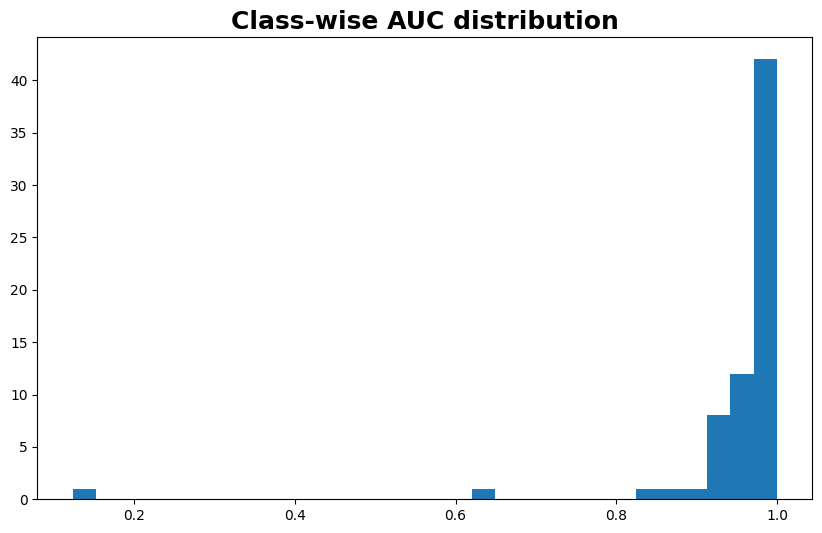

In [50]:
if not IS_TEST_ENV:
    auc_list = []
    for i, col in enumerate(species_cols):
        y_true = gt_array[:, i]
        y_pred = pred[:, i]
    
        # NO positive: skip
        if y_true.sum() == 0:
            continue
    
        auc = roc_auc_score(y_true, y_pred)
        auc_list.append({
            "species"  : col,
            "auc"      : auc,
            "pos_count": int(y_true.sum())
        })
    
    auc_df = pd.DataFrame(auc_list)

    display(auc_df.sort_values("auc").head(10))
    display(auc_df.sort_values("auc", ascending=False).head(10))
    display(auc_df.sort_values("pos_count").head(10))

    plt.figure(figsize=(10, 6))
    plt.hist(auc_df["auc"], bins=30)
    plt.title("Class-wise AUC distribution", size=18, fontweight="bold")
    plt.show()